In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [54]:
df = pd.read_csv('data_2025')

In [56]:
df = df.copy()

# Map common Statcast variants → our canonical names
rename_map = {}
if "release_extension" in df.columns and "extension" not in df.columns:
    rename_map["release_extension"] = "extension"
# (Add other rare aliases here if you encounter them)

if rename_map:
    df = df.rename(columns=rename_map)

# Make sure numeric fields exist & are numeric
num_cols = ["release_speed","pfx_x","pfx_z","release_pos_z","extension"]
for c in num_cols:
    if c not in df.columns:
        df[c] = np.nan
    df[c] = pd.to_numeric(df[c], errors="coerce")

# --- 1) Helper: pick first existing column name ---
def first_col(cols, candidates):
    s = set(cols)
    for c in candidates:
        if c in s:
            return c
    return None

cols = df.columns.tolist()

# --- 2) One row per pitcher (with name) ---
pitcher_name_col = first_col(cols, [
    "pitcher_name","player_name_pitcher","pitcher_full_name","player_name_x","player_name"
])
print("Using pitcher name column:", pitcher_name_col)

p_idx_cols = ["pitcher","p_throws"]
if pitcher_name_col: p_idx_cols.append(pitcher_name_col)

pitcher_index = (
    df[p_idx_cols]
      .dropna(subset=["pitcher"])
      .drop_duplicates(subset=["pitcher"])
      .copy()
)
if pitcher_name_col:
    pitcher_index = pitcher_index.rename(columns={pitcher_name_col: "pitcher_name"})
else:
    pitcher_index["pitcher_name"] = "(ID " + pitcher_index["pitcher"].astype(str) + ")"

pitcher_index = pitcher_index.sort_values("pitcher_name").reset_index(drop=True)
pitcher_index.to_parquet("artifacts/pitcher_index_2025.parquet", index=False)
print("Wrote artifacts/pitcher_index_2025.parquet", len(pitcher_index))

# --- 3) Per-pitcher x pitch_type medians (arsenal) — include only columns that exist ---
agg = {
    "n": ("pitch_number","count"),
    "p_throws": ("p_throws","first"),
}
if "release_speed" in df:  agg["release_speed"]  = ("release_speed","median")
if "pfx_x"         in df:  agg["pfx_x"]          = ("pfx_x","median")
if "pfx_z"         in df:  agg["pfx_z"]          = ("pfx_z","median")
if "release_pos_z" in df:  agg["release_pos_z"]  = ("release_pos_z","median")
if "extension"     in df:  agg["extension"]      = ("extension","median")

arsenal = (
    df.groupby(["pitcher","pitch_type"], as_index=False)
      .agg(**agg)
)
arsenal.to_parquet("artifacts/pitcher_arsenal_2025.parquet", index=False)
print("Wrote artifacts/pitcher_arsenal_2025.parquet", len(arsenal))

# --- 4) One row per batter (IDs only, per your request) ---
batters = (
    df[["batter","stand"]]
      .dropna(subset=["batter"])
      .drop_duplicates(subset=["batter"])
      .sort_values("batter")
      .reset_index(drop=True)
)
batters.to_parquet("artifacts/batters_2025.parquet", index=False)
print("Wrote artifacts/batters_2025.parquet", len(batters))

# --- 5) (Optional) outcome_erv lookup, if you haven’t saved it yet ---
# (Keep your existing code for this; nothing to change here.)


Using pitcher name column: player_name
Wrote artifacts/pitcher_index_2025.parquet 1196
Wrote artifacts/pitcher_arsenal_2025.parquet 4716
Wrote artifacts/batters_2025.parquet 1436


In [58]:
# --- Make a robust 'half' column and ensure prerequisites for Step 4 ---

import numpy as np
import pandas as pd

def normalize_topbot_col(df):
    if "inning_topbot" in df.columns:
        s = df["inning_topbot"].astype(str).str.strip().str.lower()
        return (s.replace({"top":"Top","t":"Top","bot":"Bottom","bottom":"Bottom"})
                 .where(~s.isin(["top","t","0"]), "Top")
                 .where(~s.isin(["bottom","bot","1"]), "Bottom"))
    if "top" in df.columns:
        return df["top"].map({True:"Top", False:"Bottom"})
    if "inning_top" in df.columns:
        return df["inning_top"].map({1:"Top", 0:"Bottom"})
    if "inning_top_flag" in df.columns:
        return df["inning_top_flag"].map({1:"Top", 0:"Bottom"})
    raise KeyError("Could not infer half-inning (no inning_topbot/top/inning_top/_flag column).")

# Ensure we have the keys Step 4 uses
need_int = ["game_pk","inning","at_bat_number","pitch_number"]
for c in need_int:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Create 'half'
df["half"] = normalize_topbot_col(df)

# If _runs_remaining is missing, build it now (so Step 4 can take deltas)
if "_runs_remaining" not in df.columns:
    if not {"home_score","away_score"}.issubset(df.columns):
        raise KeyError("Need home_score and away_score to compute _runs_remaining.")
    bat_runs_so_far = np.where(df["half"].eq("Top"), df["away_score"], df["home_score"])
    df["_bat_runs_so_far"] = bat_runs_so_far

    df = df.sort_values(["game_pk","inning","half","at_bat_number","pitch_number"], kind="mergesort")
    bat_end = df.groupby(["game_pk","inning","half"], sort=False)["_bat_runs_so_far"].transform("last")
    df["_runs_remaining"] = bat_end - df["_bat_runs_so_far"]


In [59]:
# === 0) Helper: pick first existing column name ===
def first_col(cols, candidates):
    s = set(cols)
    for c in candidates:
        if c in s:
            return c
    return None

# df must be your 2025 pitch-level DataFrame (already loaded)
cols = df.columns.tolist()

# === 1) Build a clean, one-row-per-pitcher index with NAMES ===
pitcher_name_col = first_col(cols, [
    "pitcher_name",           # common
    "player_name_pitcher",    # some exports
    "pitcher_full_name",
    "player_name_x",          # merge suffix
    "player_name"             # fallback (sometimes pitcher)
])
print("Using pitcher name column:", pitcher_name_col)

p_idx_cols = ["pitcher", "p_throws"]
if pitcher_name_col: p_idx_cols.append(pitcher_name_col)

pitcher_index = (
    df[p_idx_cols]
      .dropna(subset=["pitcher"])
      .drop_duplicates(subset=["pitcher"])
      .copy()
)

if pitcher_name_col:
    pitcher_index = pitcher_index.rename(columns={pitcher_name_col: "pitcher_name"})
else:
    pitcher_index["pitcher_name"] = "(ID " + pitcher_index["pitcher"].astype(str) + ")"

pitcher_index = pitcher_index.sort_values("pitcher_name").reset_index(drop=True)
pitcher_index.to_parquet("artifacts/pitcher_index_2025.parquet", index=False)
print("Wrote artifacts/pitcher_index_2025.parquet", len(pitcher_index))

# === 2) Build per-pitcher x pitch_type medians for autofill (arsenal) ===
arsenal = (
    df.groupby(["pitcher","pitch_type"], as_index=False)
      .agg(
          n=("pitch_number","count"),
          release_speed=("release_speed","median"),
          pfx_x=("pfx_x","median"),
          pfx_z=("pfx_z","median"),
          release_pos_z=("release_pos_z","median"),
          extension=("extension","median"),
          p_throws=("p_throws","first")
      )
)
arsenal.to_parquet("artifacts/pitcher_arsenal_2025.parquet", index=False)
print("Wrote artifacts/pitcher_arsenal_2025.parquet", len(arsenal))

# === 3) Build a simple one-row-per-batter table (IDs only, as requested) ===
batters = (
    df[["batter","stand"]]
      .dropna(subset=["batter"])
      .drop_duplicates(subset=["batter"])
      .sort_values("batter")
      .reset_index(drop=True)
)
batters.to_parquet("artifacts/batters_2025.parquet", index=False)
print("Wrote artifacts/batters_2025.parquet", len(batters))

# === 4) (Optional but recommended) Save outcome_erv lookup used by the app ===
d = df.sort_values(["game_pk","inning","half","at_bat_number","pitch_number"]).copy()
d["_runs_remaining_next"] = d.groupby(["game_pk","inning","half"])["_runs_remaining"].shift(-1).fillna(0.0)
d["delta"] = d["_runs_remaining_next"] - d["_runs_remaining"]

def outcome_class(row):
    dsc = str(row["description"]).lower()
    if dsc in ("ball","blocked_ball","pitchout"): return "Ball"
    if dsc == "called_strike":                    return "CalledStrike"
    if dsc in ("swinging_strike","swinging_strike_blocked"): return "SwingingStrike"
    if dsc == "foul": return "Foul"
    if "in_play" in dsc or pd.notna(row.get("events")):
        ev, la = row.get("launch_speed"), row.get("launch_angle")
        if pd.notna(ev) and pd.notna(la) and not (ev < 85 or la < 0):
            return "InPlaySolid"
        return "InPlayWeak"
    return None

d["base_state"] = (d["on_1b"].notna().astype(int).astype(str) +
                   d["on_2b"].notna().astype(int).astype(str) +
                   d["on_3b"].notna().astype(int).astype(str))
d["y_class"] = d.apply(outcome_class, axis=1)

outcome_erv = (d.dropna(subset=["y_class"])
                 .groupby(["base_state","outs_when_up","y_class"], as_index=False)["delta"].mean()
                 .rename(columns={"outs_when_up":"outs","delta":"ERV"}))
outcome_erv.to_csv("artifacts/outcome_erv_lookup_2025.csv", index=False)
print("Wrote artifacts/outcome_erv_lookup_2025.csv", len(outcome_erv))


Using pitcher name column: player_name
Wrote artifacts/pitcher_index_2025.parquet 1196
Wrote artifacts/pitcher_arsenal_2025.parquet 4716
Wrote artifacts/batters_2025.parquet 1436
Wrote artifacts/outcome_erv_lookup_2025.csv 144


In [40]:
re = df.copy()
re = re[re["outs_when_up"].between(0,2)]
re["base_state"] = base_state_code(re)

re24_2025 = (
    re.groupby(["base_state","outs_when_up"], as_index=False)["_runs_remaining"]
      .mean()
      .rename(columns={"outs_when_up":"outs","_runs_remaining":"RE"})
      .sort_values(["outs","base_state"])
)

re24_2025.head()


,base_state,outs,RE
0,000,0,0.488820
3,001,0,1.320312
6,010,0,1.086060
9,011,0,1.880610
12,100,0,0.876514


In [41]:
# Keep plausible counts and taken-pitch events
c = df.copy()
c = c[c["balls"].between(0,3) & c["strikes"].between(0,2)]
c["event_type"] = c["description"].str.lower().map({
    "ball":"Ball", "blocked_ball":"Ball", "pitchout":"Ball",
    "called_strike":"CalledStrike"
})
c = c[c["event_type"].notna()]

# Pre-pitch context
c["base_state"] = base_state_code(c)

# Next-pitch runs_remaining within the same half; if none (last pitch), use 0
c["_runs_remaining_next"] = lead_within_half_inning(c, "_runs_remaining").fillna(0.0)

# Delta = (future runs after this pitch) - (future runs before this pitch)
c["delta"] = c["_runs_remaining_next"] - c["_runs_remaining"]

count_re_2025 = (
    c.groupby(["base_state","outs_when_up","balls","strikes","event_type"], as_index=False)["delta"]
     .mean()
     .rename(columns={"outs_when_up":"outs","delta":"ERV"})
     .sort_values(["outs","base_state","balls","strikes","event_type"])
)

count_re_2025.head()

,base_state,outs,balls,strikes,event_type,ERV
0,000,0,0,0,Ball,-0.016638
1,000,0,0,0,CalledStrike,-0.013791
2,000,0,0,1,Ball,-0.021103
3,000,0,0,1,CalledStrike,-0.010725
4,000,0,0,2,Ball,-0.018692


In [42]:
# RE24 shapes: 8 base states (000..111) × outs {0,1,2} = up to 24 rows
re24_2025.shape, re24_2025.head(10)

# Count ERV: should include both 'Ball' and 'CalledStrike' across many counts
count_re_2025['event_type'].value_counts(), count_re_2025.sample(10)


(event_type
 Ball            288
 CalledStrike    288
 Name: count, dtype: int64,
     base_state  outs  balls  strikes    event_type       ERV
 59         000     2      1        2  CalledStrike  0.000000
 468        110     1      2        0          Ball -0.021739
 483        110     2      0        1  CalledStrike -0.103943
 215        010     2      3        2  CalledStrike  0.000000
 202        010     2      1        2          Ball -0.102970
 209        010     2      2        2  CalledStrike  0.000000
 392        101     1      1        1          Ball -0.306122
 305        100     0      2        2  CalledStrike -0.023438
 194        010     2      0        1          Ball -0.090909
 373        101     0      2        0  CalledStrike -0.434783)

BLOCK

In [43]:
import numpy as np
import pandas as pd

# tune these if you prefer a 5x5 later
ZX = [-0.95, -0.32, 0.32, 0.95]  # x boundaries (in feet) roughly edge-to-edge
ZZ = [1.5, 2.3, 3.1, 3.9]        # z boundaries (in feet) roughly bottom/top of zone

def zone_bucket(row):
    x, z = row["plate_x"], row["plate_z"]
    # In-zone 3x3
    if ZX[0] <= x < ZX[-1] and ZZ[0] <= z < ZZ[-1]:
        ix = np.searchsorted(ZX, x, side="right") - 1
        iz = np.searchsorted(ZZ, z, side="right") - 1
        return f"Z{iz}{ix}"   # Z00 bottom-in, Z22 top-away, etc.
    # Out-of-zone bands (up/down/in/away)
    if z >= ZZ[-1]:   return "OOZ_UP"
    if z <  ZZ[0]:    return "OOZ_DOWN"
    if x <= ZX[0]:    return "OOZ_IN"
    if x >= ZX[-1]:   return "OOZ_AWAY"
    return "OOZ_MISC"

df["grid_cell"] = df.apply(zone_bucket, axis=1)


In [44]:
def outcome_class(row):
    d = str(row["description"]).lower()
    if d in ("ball","blocked_ball","pitchout"):           return "Ball"
    if d == "called_strike":                              return "CalledStrike"
    if d in ("swinging_strike","swinging_strike_blocked"):return "SwingingStrike"
    if d == "foul":                                       return "Foul"
    # in-play buckets from EV/LA (tweak thresholds if you like)
    if "in_play" in d or pd.notna(row.get("events")):
        ev = row.get("launch_speed", np.nan)
        la = row.get("launch_angle", np.nan)
        if pd.notna(ev) and pd.notna(la):
            if (ev < 85) or (la < 0):
                return "InPlayWeak"
            else:
                return "InPlaySolid"
        # fallback if no EV/LA:
        return "InPlayWeak"
    return None  # drop rare/other events for the model

df["y_class"] = df.apply(outcome_class, axis=1)
df = df[df["y_class"].notna()].copy()


In [46]:
# Base-out state code for features/ERV joins
def base_state_code_local(r):
    b1 = int(pd.notna(r["on_1b"]))
    b2 = int(pd.notna(r["on_2b"]))
    b3 = int(pd.notna(r["on_3b"]))
    return f"{b1}{b2}{b3}"

df["base_state"] = df.apply(base_state_code_local, axis=1)

# Keep only columns we need
keep_cols = [
    "game_pk","inning","half","at_bat_number","pitch_number",
    "pitcher","batter","p_throws","stand",
    "balls","strikes","outs_when_up","base_state",
    "pitch_type","release_speed","pfx_x","pfx_z","release_pos_z","extension",
    "plate_x","plate_z","grid_cell",
    "y_class","_runs_remaining"  # for ERV calibration later
]
Xdf = df[keep_cols].dropna(subset=["pitch_type","grid_cell","release_speed","pfx_x","pfx_z","release_pos_z","extension"])

# Encode categoricals
cat_cols = ["pitch_type","grid_cell","p_throws","stand"]
num_cols = ["release_speed","pfx_x","pfx_z","release_pos_z","extension","balls","strikes","outs_when_up"]
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
pre = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

y = Xdf["y_class"].astype("category")
X = Xdf[cat_cols + num_cols]


In [47]:
from sklearn.model_selection import train_test_split

pitchers = Xdf["pitcher"].drop_duplicates().values
train_pitchers, test_pitchers = train_test_split(pitchers, test_size=0.2, random_state=42)

train_idx = Xdf["pitcher"].isin(train_pitchers)
test_idx  = Xdf["pitcher"].isin(test_pitchers)

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

In [48]:
clf = LogisticRegression(
    multi_class="multinomial",
    max_iter=500,
    class_weight="balanced",
    n_jobs=None,
    solver="lbfgs"
)

pipe = Pipeline(steps=[("pre", pre), ("clf", clf)])
pipe.fit(X_train, y_train)

from sklearn.metrics import classification_report, log_loss
y_proba = pipe.predict_proba(X_test)
y_pred  = pipe.predict(X_test)

print(classification_report(y_test, y_pred))
print("Log loss:", log_loss(y_test, y_proba, labels=pipe.classes_))
pipe.classes_


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                precision    recall  f1-score   support

          Ball       0.76      0.71      0.73     53769
  CalledStrike       0.43      0.69      0.53     25156
          Foul       0.34      0.15      0.21     27085
   InPlaySolid       0.23      0.32      0.27     13444
    InPlayWeak       0.22      0.23      0.23     14526
SwingingStrike       0.18      0.15      0.17     16367

      accuracy                           0.46    150347
     macro avg       0.36      0.38      0.36    150347
  weighted avg       0.47      0.46      0.45    150347

Log loss: 1.3805261965637037


array(['Ball', 'CalledStrike', 'Foul', 'InPlaySolid', 'InPlayWeak',
       'SwingingStrike'], dtype=object)

In [49]:
import json, joblib, pathlib
pathlib.Path("artifacts").mkdir(exist_ok=True)
joblib.dump(pipe, "artifacts/next_pitch_outcome_model.pkl")

feature_columns = {
    "categorical": cat_cols,
    "numerical": num_cols,
    "classes": pipe.classes_.tolist()
}
with open("artifacts/feature_columns.json","w") as f:
    json.dump(feature_columns, f, indent=2)

print("Saved artifacts/next_pitch_outcome_model.pkl and artifacts/feature_columns.json")


Saved artifacts/next_pitch_outcome_model.pkl and artifacts/feature_columns.json


In [50]:
# (a) Outcome ERV by base_state & outs, using runs_remaining deltas like before
def lead_runs_remaining_local(g):
    return g["_runs_remaining"].shift(-1).fillna(0.0)

d_erv = df.copy()
d_erv = d_erv.sort_values(["game_pk","inning","half","at_bat_number","pitch_number"])
d_erv["_runs_remaining_next"] = d_erv.groupby(["game_pk","inning","half"], sort=False)["_runs_remaining"].shift(-1).fillna(0.0)
d_erv["delta"] = d_erv["_runs_remaining_next"] - d_erv["_runs_remaining"]

outcome_erv = (
    d_erv.groupby(["base_state","outs_when_up","y_class"], as_index=False)["delta"].mean()
        .rename(columns={"outs_when_up":"outs","delta":"ERV"})
)

# (b) Load the two tables you built earlier for count-aware takes
re24 = pd.read_csv("re24_2025.csv")
count_re = pd.read_csv("count_re_2025.csv")

# Helper to fetch ERV for a specific event at this count/base-out
def count_event_erv(base_state, outs, balls, strikes, event_type):
    row = count_re[
        (count_re.base_state==base_state)&(count_re.outs==outs)&
        (count_re.balls==balls)&(count_re.strikes==strikes)&
        (count_re.event_type==event_type)
    ]
    if len(row):
        return float(row["ERV"].iloc[0])
    # fallback: average across counts
    row = count_re[(count_re.base_state==base_state)&(count_re.outs==outs)&(count_re.event_type==event_type)]
    if len(row): return float(row["ERV"].mean())
    # global fallback
    return 0.0


In [51]:
def predict_pitch_outcome_and_erv(model, *, pitcher, batter, p_throws, stand,
                                  balls, strikes, outs, base_state,
                                  pitch_type, release_speed, pfx_x, pfx_z, release_pos_z, extension,
                                  plate_x, plate_z, grid_cell=None):
    # Prepare a one-row DataFrame matching training schema
    if grid_cell is None:
        grid_cell = zone_bucket(pd.Series({"plate_x":plate_x,"plate_z":plate_z}))
    row = pd.DataFrame([{
        "pitch_type": pitch_type,
        "grid_cell": grid_cell,
        "p_throws": p_throws,
        "stand": stand,
        "release_speed": release_speed,
        "pfx_x": pfx_x,
        "pfx_z": pfx_z,
        "release_pos_z": release_pos_z,
        "extension": extension,
        "balls": balls,
        "strikes": strikes,
        "outs_when_up": outs
    }])
    probs = model.predict_proba(row)[0]
    classes = model.classes_

    # ERV: use count-aware for Ball/CalledStrike; outcome-based for others
    ev = 0.0
    for cls, p in zip(classes, probs):
        if cls in ("Ball","CalledStrike"):
            ev_i = count_event_erv(base_state, outs, balls, strikes, "Ball" if cls=="Ball" else "CalledStrike")
        else:
            # fallback to outcome_erv by base_state/outs (ignore count)
            sel = outcome_erv[(outcome_erv.base_state==base_state)&(outcome_erv.outs==outs)&(outcome_erv.y_class==cls)]
            ev_i = float(sel["ERV"].iloc[0]) if len(sel) else 0.0
        ev += p * ev_i

    return dict(
        probs=dict(zip(classes, probs)),
        expected_run_value=ev,
        grid_cell=grid_cell
    )

# Example (fill with realistic values for a given matchup):
# res = predict_pitch_outcome_and_erv(pipe,
#     pitcher=000000, batter=000000, p_throws="R", stand="L",
#     balls=1, strikes=1, outs=1, base_state="100",
#     pitch_type="FF", release_speed=96.2, pfx_x=-0.5, pfx_z=15.8,
#     release_pos_z=6.2, extension=6.5, plate_x=-0.2, plate_z=3.2
# )
# res


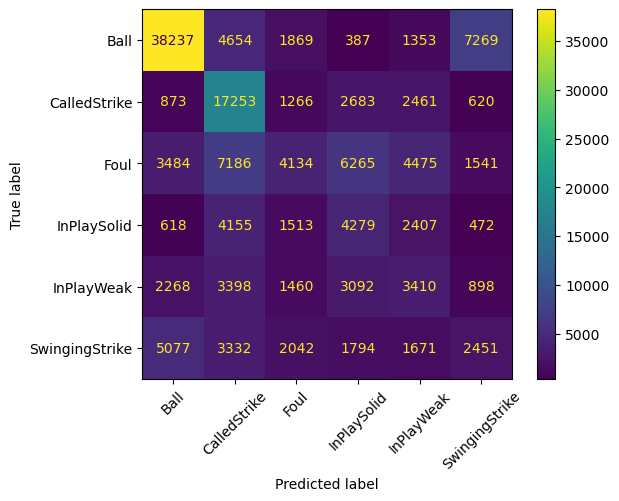

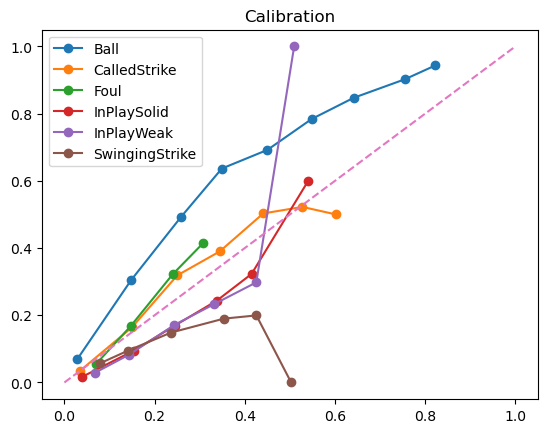

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=pipe.classes_, xticks_rotation=45)
plt.show()

# Class probability calibration check
from sklearn.calibration import calibration_curve
for cls_i, cls in enumerate(pipe.classes_):
    prob = y_proba[:, cls_i]
    y_bin = (y_test.values == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(y_bin, prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=cls)
plt.plot([0,1],[0,1], '--')
plt.legend(); plt.title("Calibration"); plt.show()


In [53]:

def first_existing(colnames, candidates):
    """Return the first column in candidates that exists in colnames, else None."""
    cols = set(colnames)
    for c in candidates:
        if c in cols:
            return c
    return None

# 1) Inspect columns and pick name fields if present
cols = df.columns.tolist()
print("Total columns:", len(cols))

pitcher_name_col = first_existing(cols, [
    "pitcher_name", "player_name_pitcher", "pitcher_full_name", "player_name_x"
])
batter_name_col  = first_existing(cols, [
    "batter_name", "player_name_batter", "batter_full_name", "player_name", "player_name_y"
])

print("Detected pitcher_name_col:", pitcher_name_col)
print("Detected batter_name_col :", batter_name_col)

# 2) Build arsenal (per pitcher x pitch_type medians) + save
agg = {
    "n": ("pitch_number", "count"),
    "release_speed": ("release_speed", "median"),
    "pfx_x": ("pfx_x", "median"),
    "pfx_z": ("pfx_z", "median"),
    "release_pos_z": ("release_pos_z", "median"),
    "extension": ("extension", "median"),
    "p_throws": ("p_throws", "first"),
}
if pitcher_name_col:
    agg["pitcher_name"] = (pitcher_name_col, "first")

arsenal = (
    df.groupby(["pitcher", "pitch_type"], as_index=False)
      .agg(**agg)
)
arsenal.to_parquet("artifacts/pitcher_arsenal_2025.parquet", index=False)

# 3) One-row-per-pitcher index (for clean dropdown, no repeats)
pitcher_index_cols = ["pitcher", "p_throws"]
if "pitcher_name" in arsenal.columns:
    pitcher_index_cols.append("pitcher_name")

pitcher_index = (
    arsenal[pitcher_index_cols]
    .drop_duplicates(subset=["pitcher"])
    .sort_values(pitcher_index_cols[-1] if "pitcher_name" in arsenal.columns else "pitcher")
)
# If no name, create a readable display later in app.py; we keep this minimal here.
pitcher_index.to_parquet("artifacts/pitcher_index_2025.parquet", index=False)

# 4) One-row-per-batter table with name if present
batter_cols = ["batter", "stand"]
if batter_name_col:
    batter_cols.append(batter_name_col)

batters = (
    df[batter_cols]
    .dropna(subset=["batter"])
    .drop_duplicates(subset=["batter"])
    .copy()
)
if batter_name_col:
    batters = batters.rename(columns={batter_name_col: "batter_name"})
else:
    batters["batter_name"] = "(ID " + batters["batter"].astype(str) + ")"

batters = batters.sort_values("batter_name")
batters.to_parquet("artifacts/batters_2025.parquet", index=False)



Total columns: 125
Detected pitcher_name_col: None
Detected batter_name_col : player_name
